In [6]:
import openmc
import openmc.deplete
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt

# ==========================
# Définition des matériaux
# ==========================

# Combustible MOX (UO2-PuO2)
UGD_fuel = openmc.Material(name='UGD Fuel')
UGD_fuel.add_nuclide('U238', 0.924)
UGD_fuel.add_nuclide('U235', 0.036)
UGD_fuel.add_element('Gd', 0.04)
UGD_fuel.set_density('g/cm3', 10.5)
UGD_fuel.temperature = 1200  # Température en K

def mox_fuel(enrichment):
    """Créer un matériau MOX avec un enrichissement donné en Pu239."""
    mox = openmc.Material()
    mox.add_element('U', 0.91)
    mox.add_nuclide('Pu239', enrichment)
    mox.add_nuclide('Pu240', 0.035)
    mox.add_nuclide('Pu241', 0.005)
    mox.add_nuclide('Pu242', 0.005)
    mox.add_nuclide('O16', 2.00)
    mox.set_density('g/cm3', 10.5)
    mox.temperature = 1200
    return mox

mox_3_6 = mox_fuel(0.08)
mox_2_7 = mox_fuel(0.067)
mox_2_4 = mox_fuel(0.052)

# Caloporteur Sodium
sodium = openmc.Material(name='Sodium')
sodium.add_nuclide('Na23', 1.0)
sodium.set_density('g/cm3', 0.927)
sodium.temperature = 600  # Température en K

# Gainage en zirconium
zirconium_cladding = openmc.Material(name='Zirconium Cladding')
zirconium_cladding.add_element('Zr', 1.0)
zirconium_cladding.set_density('g/cm3', 6.5)
zirconium_cladding.temperature = 900  # Température en K

# Gaz d'Hélium
gas_gap = openmc.Material(name='Helium Gap')
gas_gap.add_element('He', 1.0)
gas_gap.set_density('g/cm3', 0.0001786)
gas_gap.temperature = 900  # Température en K

# Définition des matériaux
materials = openmc.Materials([UGD_fuel, mox_3_6, mox_2_7, mox_2_4, sodium, gas_gap, zirconium_cladding])
materials.export_to_xml()

# ===========================
# Définition de la géométrie
# ===========================

pin_pitch = 1.25984
fuel_radius = openmc.ZCylinder(r=0.39218)
clad_inner_radius = openmc.ZCylinder(r=0.40005)
clad_outer_radius = openmc.ZCylinder(r=0.45720)
#outzone_sodium = openmc.ZCylinder(r=pin_pitch/2)

N = 11  # Nombre de couronnes de crayons
assembly_width = (N-1) * pin_pitch * sqrt(3)
assembly_pitch = assembly_width + 0.5

pin_box = openmc.model.HexagonalPrism(edge_length=pin_pitch/2, boundary_type='reflective')
assembly_box = openmc.model.HexagonalPrism(edge_length=30, boundary_type='reflective')

mox_3_6_cell = openmc.Cell(name='Fuel1', fill=mox_3_6, region=-fuel_radius)
mox_2_7_cell = openmc.Cell(name='Fuel2', fill=mox_2_7, region=-fuel_radius)
mox_2_4_cell = openmc.Cell(name='Fuel3', fill=mox_2_4, region=-fuel_radius)

UGD_cell = openmc.Cell(name='UGd', fill=UGD_fuel, region=-fuel_radius)
guide_tube_cell = openmc.Cell(name='Guide Tube',fill=zirconium_cladding, region=-clad_outer_radius)

gap_3_6_cell = openmc.Cell(name='Helium 3.6 Gap', fill=gas_gap, region=+fuel_radius & -clad_inner_radius)
gap_2_7_cell = openmc.Cell(name='Helium 2.7 Gap', fill=gas_gap, region=+fuel_radius & -clad_inner_radius)
gap_2_4_cell = openmc.Cell(name='Helium 2.4 Gap', fill=gas_gap, region=+fuel_radius & -clad_inner_radius)
gap_Ugd_cell = openmc.Cell(name='Helium Ugd Gap', fill=gas_gap, region=+fuel_radius & -clad_inner_radius)

clad_3_6_cell = openmc.Cell(name='Cladding 3.6', fill=zirconium_cladding, region=+clad_inner_radius & -clad_outer_radius)
clad_2_7_cell = openmc.Cell(name='Cladding 2.7', fill=zirconium_cladding, region=+clad_inner_radius & -clad_outer_radius)
clad_2_4_cell = openmc.Cell(name='Cladding 2.4', fill=zirconium_cladding, region=+clad_inner_radius & -clad_outer_radius)
clad_Ugd_cell = openmc.Cell(name='Cladding Ugd', fill=zirconium_cladding, region=+clad_inner_radius & -clad_outer_radius)

sodium_inner_3_6_cell = openmc.Cell(name='Coolant 3.6 inner', fill=sodium, region=+clad_outer_radius)
sodium_inner_2_7_cell = openmc.Cell(name='Coolant 2.7 inner', fill=sodium, region=+clad_outer_radius)
sodium_inner_2_4_cell = openmc.Cell(name='Coolant 2.4 inner', fill=sodium, region=+clad_outer_radius)
sodium_inner_Ugd_cell = openmc.Cell(name='Coolant Ugd inner', fill=sodium, region=+clad_outer_radius)
sodium_inner_GT_cell = openmc.Cell(name='Coolant GT inner', fill=sodium, region=+clad_outer_radius)

sodium_outer_cell = openmc.Cell(name='Coolant outer', fill=sodium)

sodium_universe = openmc.Universe(cells=[sodium_outer_cell])
guide_tube_universe = openmc.Universe(cells=[guide_tube_cell,sodium_inner_GT_cell])

mox_3_6_universe = openmc.Universe(cells=[mox_3_6_cell, gap_3_6_cell, clad_3_6_cell,sodium_inner_3_6_cell])
mox_2_7_universe = openmc.Universe(cells=[mox_2_7_cell, gap_2_7_cell, clad_2_7_cell,sodium_inner_2_7_cell])
mox_2_4_universe = openmc.Universe(cells=[mox_2_4_cell, gap_2_4_cell, clad_2_4_cell,sodium_inner_2_4_cell])
UGD_universe = openmc.Universe(cells=[UGD_cell, gap_Ugd_cell, clad_Ugd_cell,sodium_inner_Ugd_cell])

lattice = openmc.HexLattice(lattice_id=200)
lattice.center = (0.0, 0.0)
lattice.pitch = [pin_pitch]
lattice.outer = sodium_universe
lattice.universes = [
    ([mox_2_4_universe] + [mox_2_7_universe] * 9) * 6,
    ([UGD_universe] + [mox_3_6_universe] * 8 ) * 6,
    ([mox_3_6_universe] * 4 + [UGD_universe] + [mox_3_6_universe] * 3) * 6,
    ([mox_3_6_universe] * 7) * 6,
    ([mox_3_6_universe] * 3 + [guide_tube_universe] + [mox_3_6_universe] * 2) * 6,
    ([guide_tube_universe] + [mox_3_6_universe] * 4) * 6,
    ([mox_3_6_universe] * 3 + [UGD_universe]) * 6,
    ([guide_tube_universe] + [mox_3_6_universe] + [mox_3_6_universe]) * 6,
    ([mox_3_6_universe] + [mox_3_6_universe]) * 6,
    [mox_3_6_universe] * 6,
    [guide_tube_universe]
]
for i, universe in enumerate([mox_3_6_universe, mox_2_7_universe, mox_2_4_universe, UGD_universe]):
    print(f"Univers {i+1}: {universe} (Type: {type(universe)})")
    
assembly_cell = openmc.Cell(fill=lattice, region=-assembly_box)
root_universe = openmc.Universe(cells=[assembly_cell])
geometry = openmc.Geometry(root_universe)
geometry.export_to_xml()

# ===========================
# Définition de la physique
# ===========================

source = openmc.Source()
source.space = openmc.stats.Point(
    (0, -pin_pitch, 0.0)  # Point
)
source.angle = openmc.stats.Isotropic()
source.energy = openmc.stats.Watt(a=0.988, b=2.249)

settings = openmc.Settings()
settings.batches = 70
settings.inactive = 10
settings.particles = 10000
settings.source = source
settings.run_mode = 'eigenvalue'
settings.temperature = {'method': 'interpolation', 'range': (300, 1200)} # Interpolation des XS pour les températures inexistantes dans l'ENDF/B-VII.1
settings.export_to_xml()

# ===========================
# Vérification de la géométrie
# ===========================

plot_xy = openmc.Plot(plot_id=1)
plot_xy.filename = 'plot_xy'
plot_xy.origin = [0, 0, 0]
plot_xy.width = [6, 6]
plot_xy.pixels = [400, 400]
plot_xy.color_by = 'material'

plot_yz = openmc.Plot(plot_id=2)
plot_yz.filename = 'plot_yz'
plot_yz.basis = 'yz'
plot_yz.origin = [0, 0, 0]
plot_yz.width = [40, 40]
plot_yz.pixels = [400, 400]
plot_yz.color_by = 'material'

# Instantiate a Plots collection, add plots, and export to XML
plot_file = openmc.Plots((plot_xy, plot_yz))
plot_file.export_to_xml()

# ===========================
# Définition du modèle OpenMC avec variation 
# ===========================

sodium_temperatures = np.arange(600, 800, 20)  # Températures du sodium
void_fractions = [1.0, 0.5, 0.0]  # 100%, 50%, 0% de sodium (vide total)

# Dictionnaire pour stocker les résultats
results = {}

# Boucle sur les fractions de vide
keff_values = []
keff_errors = []

for T in sodium_temperatures:

    sodium.temperature = T
    materials.export_to_xml()

    # Définir un modèle OpenMC avec les nouveaux paramètres
    model = openmc.Model(geometry=geometry, settings=settings, materials=materials)

    # Exécuter la simulation
    openmc.run()

    # Lire les résultats de k-eff
    sp = openmc.StatePoint('statepoint.70.h5')
    keff = sp.k_combined
    keff_values.append(keff.nominal_value)
    keff_errors.append(keff.std_dev)
    sp.close()

# Stocker les résultats
results[void] = (keff_values, keff_errors)

# 📊 Tracer les courbes pour chaque fraction de vide
plt.figure(figsize=(8, 5))

colors = ['blue', 'red', 'green']
labels = ['100% Sodium', '50% Sodium', '0% Sodium (Vide)']

for i, void in enumerate(void_fractions):
    keff_values, keff_errors = results[void]
    plt.errorbar(sodium_temperatures, keff_values, yerr=keff_errors, fmt='o-', 
                 capsize=5, label=labels[i], color=colors[i])

# 🔹 Mise en forme du graphique
plt.xlabel("Température du sodium (K)", fontsize=12, fontweight='bold')
plt.ylabel("k-eff", fontsize=12, fontweight='bold')
plt.title("Impact de la température du sodium sur la réactivité", fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.savefig("impact_temperature_sodium_multi.png", dpi=300, bbox_inches='tight')
plt.show()


/Users/damienquillaud/miniconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Lattice instance already exists with id=200.
  warn(msg, IDWarning)
/Users/damienquillaud/miniconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/source.py:656: FutureWarning: This class is deprecated in favor of 'IndependentSource'
  warnings.warn("This class is deprecated in favor of 'IndependentSource'", FutureWarning)
/Users/damienquillaud/miniconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another PlotBase instance already exists with id=1.
  warn(msg, IDWarning)
/Users/damienquillaud/miniconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another PlotBase instance already exists with id=2.
  warn(msg, IDWarning)


Univers 1: Universe
	ID             =	24
	Name           =	
	Geom           =	CSG
	Cells          =	[61, 66, 70, 74]
 (Type: <class 'openmc.universe.Universe'>)
Univers 2: Universe
	ID             =	25
	Name           =	
	Geom           =	CSG
	Cells          =	[62, 67, 71, 75]
 (Type: <class 'openmc.universe.Universe'>)
Univers 3: Universe
	ID             =	26
	Name           =	
	Geom           =	CSG
	Cells          =	[63, 68, 72, 76]
 (Type: <class 'openmc.universe.Universe'>)
Univers 4: Universe
	ID             =	27
	Name           =	
	Geom           =	CSG
	Cells          =	[64, 69, 73, 77]
 (Type: <class 'openmc.universe.Universe'>)
                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                         

/Users/damienquillaud/miniconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/statepoint.py:277: FutureWarning: The 'k_combined' property has been renamed to 'keff' and will be removed in a future version of OpenMC.
  warnings.warn(


                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

/Users/damienquillaud/miniconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/statepoint.py:277: FutureWarning: The 'k_combined' property has been renamed to 'keff' and will be removed in a future version of OpenMC.
  warnings.warn(


...

/Users/damienquillaud/miniconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/statepoint.py:277: FutureWarning: The 'k_combined' property has been renamed to 'keff' and will be removed in a future version of OpenMC.
  warnings.warn(


                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

/Users/damienquillaud/miniconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/statepoint.py:277: FutureWarning: The 'k_combined' property has been renamed to 'keff' and will be removed in a future version of OpenMC.
  warnings.warn(


KeyError: 1.0

<Figure size 800x500 with 0 Axes>

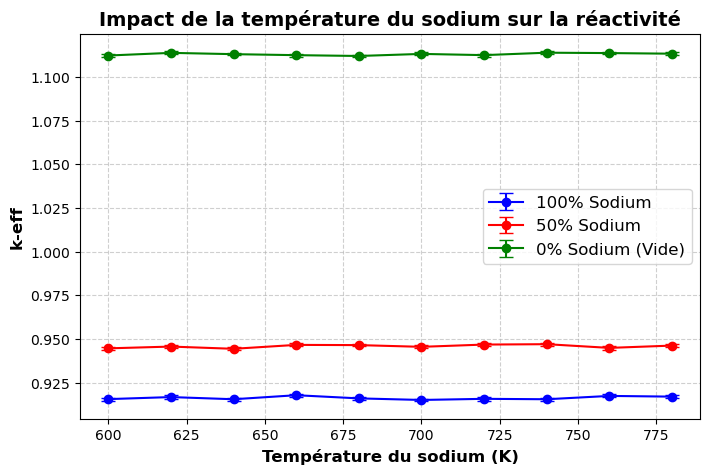

In [12]:
sodium_temperatures = np.arange(600, 800, 20)  # Températures du sodium
void_fractions = [1.0, 0.5, 0.0]  # 100%, 50%, 0% de sodium (vide total)

plt.figure(figsize=(8, 5))

colors = ['blue', 'red', 'green']
labels = ['100% Sodium', '50% Sodium', '0% Sodium (Vide)']

results = {1.0: ([0.9155779618302394, 0.9167416513713019, 0.9155027260981107, 0.9178072527225064, 0.9159947092780186, 0.9150915704794408, 0.9157376896714439, 0.9154965182602337, 0.9174057258767369, 0.9169951837565656], [0.0008210303919287357, 0.0009726872047593645, 0.000833580308576628, 0.0007708975840088236, 0.0007171707553667218, 0.000723623593063211, 0.0010174394207794041, 0.0009258986533385383, 0.0008115443611167416, 0.0007652834172453722]), 
0.5: ([0.9446291903713238, 0.9456458520420611, 0.944374268851133, 0.9466119534108944, 0.9464863608090325, 0.945500215166708, 0.946794639358487, 0.9470136956548075, 0.944894309758625, 0.9462099639902639], [0.0007986658843118557, 0.0006351027279529287, 0.0008051947353927621, 0.000809576626973644, 0.0007887347883220197, 0.0008801512545986536, 0.0006779033369564202, 0.0009115041381605337, 0.0009901603934330994, 0.0007322175034797407]),
0.0: ([1.1122384540181813, 1.1137602111235871, 1.113014361060459, 1.1124464013478348, 1.1119750851125498, 1.1131634302744933, 1.1124615087045155, 1.1138515764154622, 1.1136352584851952, 1.1132851973979228], [0.0007561783063819877, 0.00082832604700853, 0.0007365429226727959, 0.0009297315514754142, 0.000751765772038218, 0.0008279110549496407, 0.0008912451620699309, 0.0008468880121790289, 0.0008061889820299735, 0.0008301677014703117])
}

for i, void in enumerate(void_fractions):
    keff_values, keff_errors = results[void]
    plt.errorbar(sodium_temperatures, keff_values, yerr=keff_errors, fmt='o-', 
                 capsize=5, label=labels[i], color=colors[i])

plt.xlabel("Température du sodium (K)", fontsize=12, fontweight='bold')
plt.ylabel("k-eff", fontsize=12, fontweight='bold')
plt.title("Impact de la température du sodium sur la réactivité", fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.savefig("impact_temperature_sodium_multi.png", dpi=300, bbox_inches='tight')
plt.show()


In [7]:
print(results)

{0.0: ([1.1122384540181813, 1.1137602111235871, 1.113014361060459, 1.1124464013478348, 1.1119750851125498, 1.1131634302744933, 1.1124615087045155, 1.1138515764154622, 1.1136352584851952, 1.1132851973979228], [0.0007561783063819877, 0.00082832604700853, 0.0007365429226727959, 0.0009297315514754142, 0.000751765772038218, 0.0008279110549496407, 0.0008912451620699309, 0.0008468880121790289, 0.0008061889820299735, 0.0008301677014703117])}


In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Activer le style seaborn pour un rendu plus esthétique
sns.set_style("whitegrid")

# Création du graphique avec amélioration du design
plt.figure(figsize=(8, 5))  # Taille ajustée
plt.errorbar(
    sodium_temperatures, keff_values, yerr=keff_errors,
    fmt='o-', capsize=5, label="k-eff",
    markersize=6, linewidth=1.5, color="royalblue"
)

# Ajustement des axes
plt.xlabel("Température du sodium (K)", fontsize=12, fontweight='bold')
plt.ylabel("k-eff", fontsize=12, fontweight='bold')
plt.title("Impact de la température du sodium sur la réactivité", fontsize=14, fontweight='bold')

# Ajustement de l'échelle Y pour mieux visualiser les variations
plt.ylim(min(keff_values) - 0.005, max(keff_values) + 0.005)

# Ajout d'une grille plus fine
plt.grid(True, linestyle='--', alpha=0.6)

# Ajout de la légende avec un design plus visible
plt.legend(fontsize=12, loc="upper left", frameon=True)

# Sauvegarde du graphique en PNG avec haute résolution
plt.savefig("impact_temperature_sodium.png", dpi=300, bbox_inches='tight')

# Affichage du graphique
plt.show()

NameError: name 'sodium_temperatures' is not defined

<Figure size 800x500 with 0 Axes>